# Lecture 4

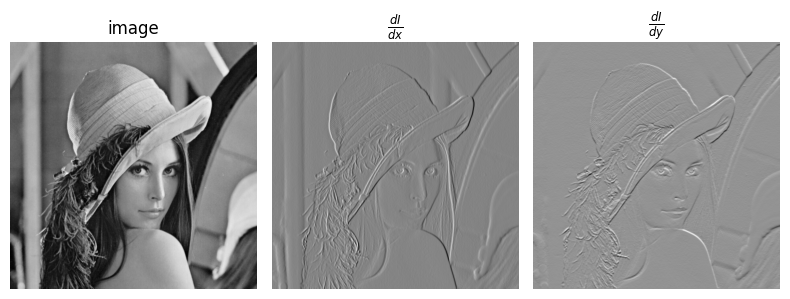

In [9]:
# 1: Sobel filter
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('./Lena.png', 0)

dx = cv2.Sobel(image, cv2.CV_32F, 1, 0)
dy = cv2.Sobel(image, cv2.CV_32F, 0, 1)

plt.figure(figsize=(8, 3))
plt.subplot(131)
plt.axis('off')
plt.title('image')
plt.imshow(image, cmap='gray')
plt.subplot(132)
plt.axis('off')
plt.imshow(dx, cmap='gray')
plt.title(r'$\frac{dI}{dx}$')
plt.subplot(133)
plt.axis('off')
plt.title(r'$\frac{dI}{dy}$')
plt.imshow(dy, cmap='gray')
plt.tight_layout()
plt.show()

(11, 11) float64 0.9999999999999992


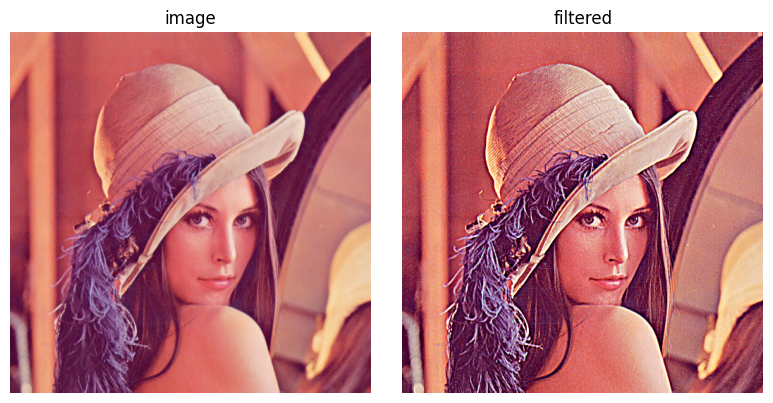

In [10]:
# 2: Unsharp mask
import cv2
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

image = cv2.imread('./Lena.png')

KSIZE = 11
ALPHA = 2
kernel = cv2.getGaussianKernel(KSIZE, 0)
kernel = -ALPHA * kernel @ kernel.T
kernel[KSIZE//2, KSIZE//2] += 1 + ALPHA
print(kernel.shape, kernel.dtype, kernel.sum())

filtered = cv2.filter2D(image, -1, kernel)

plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.axis('off')
plt.title('image')
plt.imshow(image[:, :, [2, 1, 0]])
plt.subplot(122)
plt.axis('off')
plt.title('filtered')
plt.imshow(filtered[:, :, [2, 1, 0]])
plt.tight_layout()
plt.show()

cv2.imshow('before', image)
cv2.imshow('after', filtered)
cv2.waitKey()
cv2.destroyAllWindows()

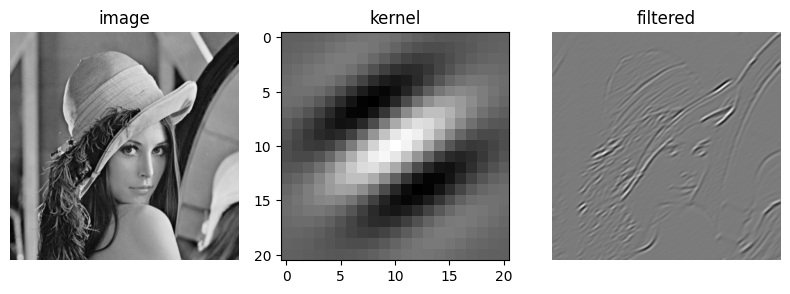

In [11]:
# 3: Gabor filter
import math
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('./Lena.png', 0).astype(np.float32) / 255

kernel = cv2.getGaborKernel((21, 21), 5, 1, 10, 1, 0, cv2.CV_32F)
kernel /= math.sqrt((kernel * kernel).sum())

filtered = cv2.filter2D(image, -1, kernel)

plt.figure(figsize=(8, 3))
plt.subplot(131)
plt.axis('off')
plt.title('image')
plt.imshow(image, cmap='gray')
plt.subplot(132)
plt.title('kernel')
plt.imshow(kernel, cmap='gray')
plt.subplot(133)
plt.axis('off')
plt.title('filtered')
plt.imshow(filtered, cmap='gray')
plt.tight_layout()
plt.show()

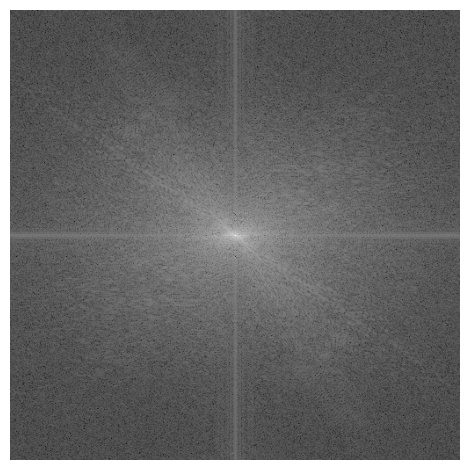

In [12]:
# 4: Discrete Fourier Transform
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('./Lena.png', 0).astype(np.float32) / 255

fft = cv2.dft(image, flags=cv2.DFT_COMPLEX_OUTPUT)

shifted = np.fft.fftshift(fft, axes=[0, 1])
magnitude = cv2.magnitude(shifted[:, :, 0], shifted[:, :, 1])
magnitude = np.log(magnitude)

plt.axis('off')
plt.imshow(magnitude, cmap='gray')
plt.tight_layout()
plt.show()

restored = cv2.idft(fft, flags=cv2.DFT_SCALE | cv2.DFT_REAL_OUTPUT)

cv2.imshow('restored', restored)
cv2.waitKey()
cv2.destroyAllWindows()

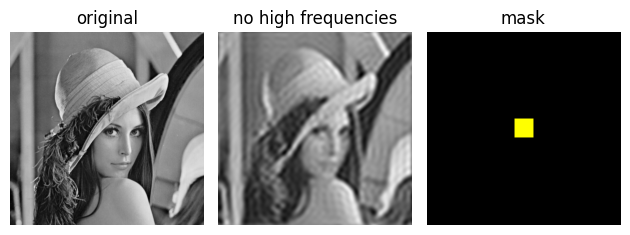

In [13]:
# 5: Frequency-based Filtering
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('./Lena.png', 0).astype(np.float32) / 255

fft = cv2.dft(image, flags=cv2.DFT_COMPLEX_OUTPUT)
fft_shift = np.fft.fftshift(fft, axes=[0, 1])
sz = 25
mask = np.zeros(fft.shape, np.uint8)
mask[image.shape[0]//2-sz:image.shape[0]//2+sz,
     image.shape[1]//2-sz:image.shape[1]//2+sz, :] = 1
fft_shift *= mask
fft = np.fft.ifftshift(fft_shift, axes=[0, 1])

filtered = cv2.idft(fft, flags=cv2.DFT_SCALE | cv2.DFT_REAL_OUTPUT)
mask_new = np.dstack((mask, np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)))

plt.figure()
plt.subplot(131)
plt.axis('off')
plt.title('original')
plt.imshow(image, cmap='gray')
plt.subplot(132)
plt.axis('off')
plt.title('no high frequencies')
plt.imshow(filtered, cmap='gray')
plt.subplot(133)
plt.axis('off')
plt.title('mask')
plt.imshow(mask_new*255, cmap='gray')
plt.tight_layout()
plt.show()

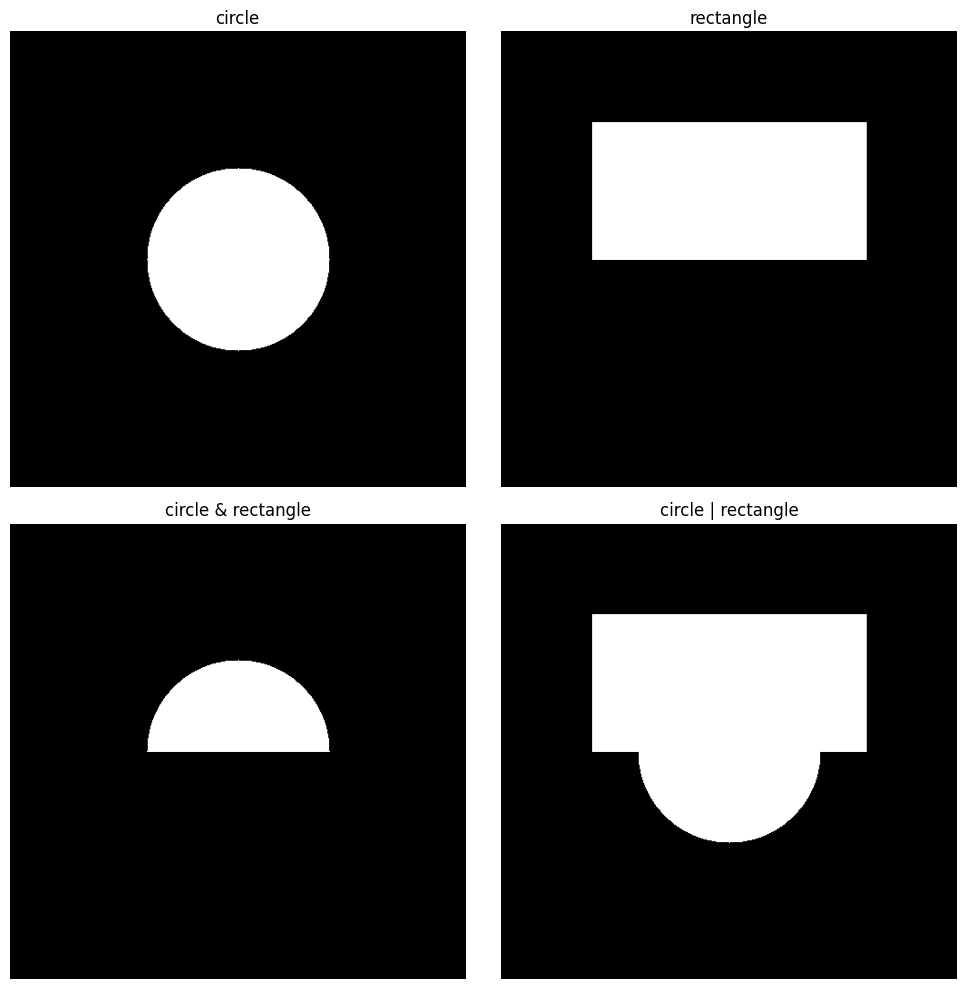

In [14]:
# 6: Binary operation
import cv2
import numpy as np
import matplotlib.pyplot as plt

circle_image = np.zeros((500, 500), np.uint8)
cv2.circle(circle_image, (250, 250), 100, 255, -1)
rect_image = np.zeros((500, 500), np.uint8)
cv2.rectangle(rect_image, (100, 100), (400, 250), 255, -1)

circle_and_rect_image = circle_image & rect_image
circle_or_rect_image = circle_image | rect_image

plt.figure(figsize=(10, 10))
plt.subplot(221)
plt.axis('off')
plt.title('circle')
plt.imshow(circle_image, cmap='gray')
plt.subplot(222)
plt.axis('off')
plt.title('rectangle')
plt.imshow(rect_image, cmap='gray')
plt.subplot(223)
plt.axis('off')
plt.title('circle & rectangle')
plt.imshow(circle_and_rect_image, cmap='gray')
plt.subplot(224)
plt.axis('off')
plt.title('circle | rectangle')
plt.imshow(circle_or_rect_image, cmap='gray')
plt.tight_layout()
plt.show()

Threshold used: 200.0


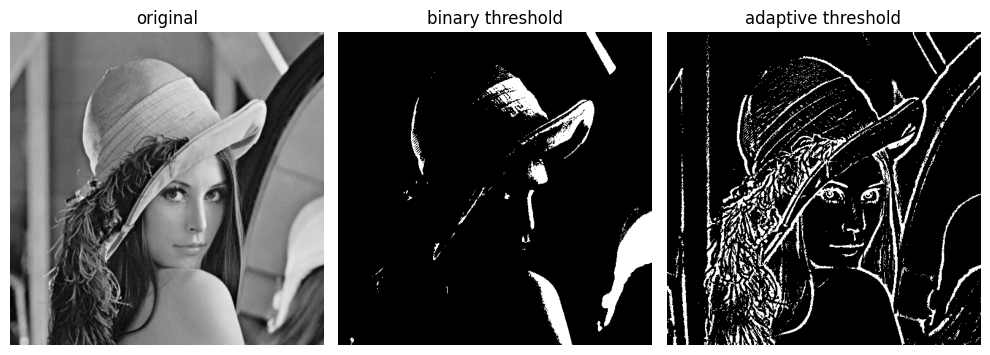

In [15]:
# 7: Image Thresholding
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('./Lena.png', 0)

thr, mask = cv2.threshold(image, 200, 1, cv2.THRESH_BINARY)
print('Threshold used:', thr)

adapt_mask = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                   cv2.THRESH_BINARY_INV, 11, 10)

plt.figure(figsize=(10, 4))
plt.subplot(131)
plt.axis('off')
plt.title('original')
plt.imshow(image, cmap='gray')
plt.subplot(132)
plt.axis('off')
plt.title('binary threshold')
plt.imshow(mask, cmap='gray')
plt.subplot(133)
plt.axis('off')
plt.title('adaptive threshold')
plt.imshow(adapt_mask, cmap='gray')
plt.tight_layout()
plt.show()

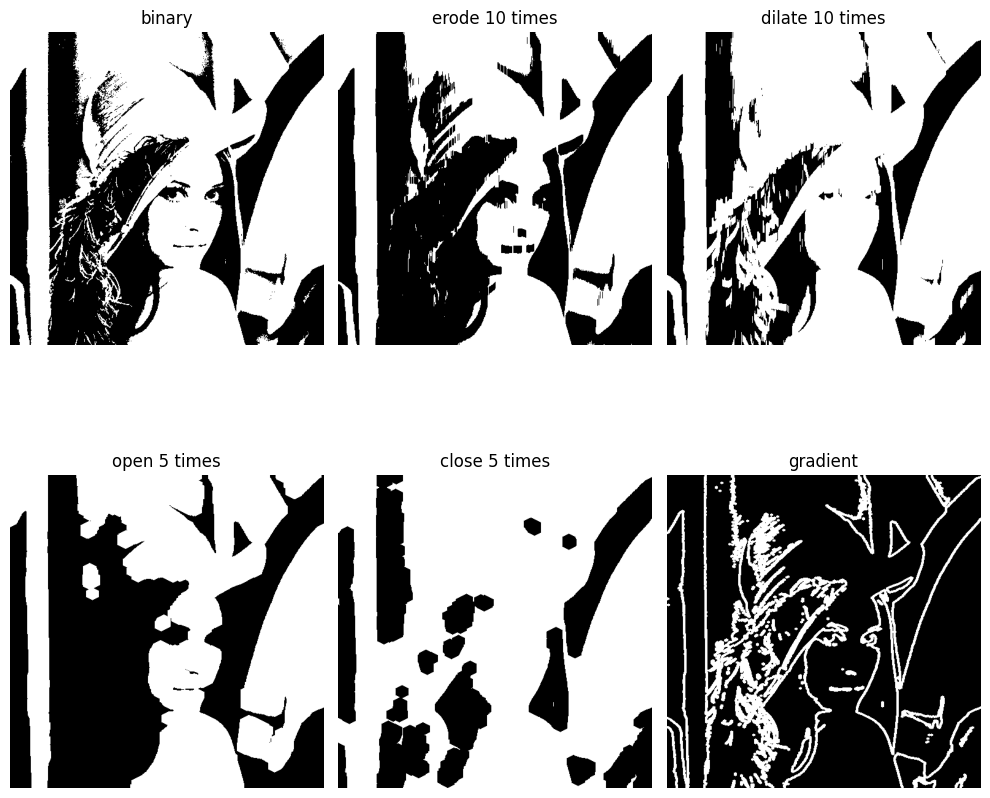

In [16]:
# 8: Morphological Filter
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('./Lena.png', 0)
_, binary = cv2.threshold(image, 1, 1, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

eroded = cv2.morphologyEx(binary, cv2.MORPH_ERODE, (3, 3), iterations=10)
dilated = cv2.morphologyEx(binary, cv2.MORPH_DILATE, (3, 3), iterations=10)

opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)), iterations=5)
closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)), iterations=5)
grad = cv2.morphologyEx(binary, cv2.MORPH_GRADIENT, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)))

plt.figure(figsize=(10, 10))
plt.subplot(231)
plt.axis('off')
plt.title('binary')
plt.imshow(binary, cmap='gray')
plt.subplot(232)
plt.axis('off')
plt.title('erode 10 times')
plt.imshow(eroded, cmap='gray')
plt.subplot(233)
plt.axis('off')
plt.title('dilate 10 times')
plt.imshow(dilated, cmap='gray')
plt.subplot(234)
plt.axis('off')
plt.title('open 5 times')
plt.imshow(opened, cmap='gray')
plt.subplot(235)
plt.axis('off')
plt.title('close 5 times')
plt.imshow(closed, cmap='gray')
plt.subplot(236)
plt.axis('off')
plt.title('gradient')
plt.imshow(grad, cmap='gray')
plt.tight_layout()
plt.show()

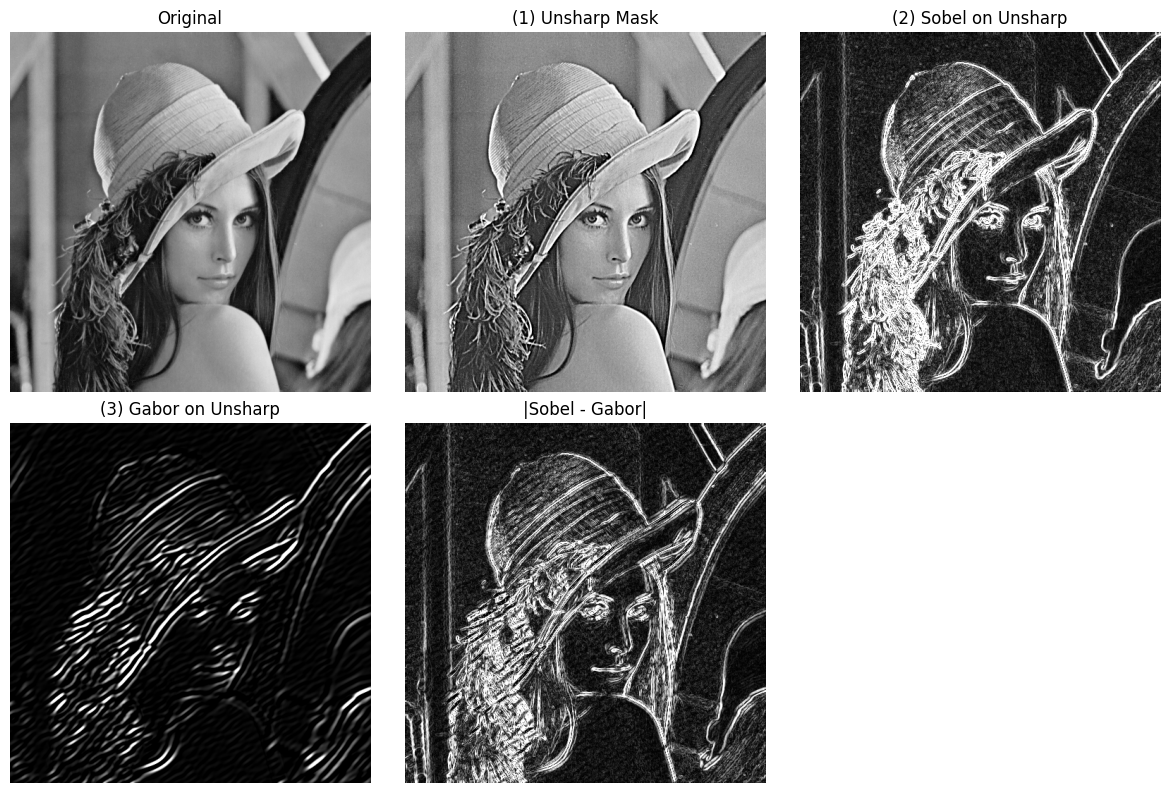

In [20]:
# 종합 실습 - Image Filtering & Frequency-based Filtering

import cv2
import numpy as np
import math
import matplotlib.pyplot as plt

# === Part 1: Image Filtering ===

# (1) 영상 출력 및 Unsharp mask 적용
image = cv2.imread('./Lena.png')
image_gray = cv2.imread('./Lena.png', 0)

KSIZE = 11
ALPHA = 2
kernel = cv2.getGaussianKernel(KSIZE, 0)
kernel = -ALPHA * kernel @ kernel.T
kernel[KSIZE//2, KSIZE//2] += 1 + ALPHA
unsharp = cv2.filter2D(image_gray, cv2.CV_32F, kernel)
unsharp_u8 = np.clip(unsharp, 0, 255).astype(np.uint8)

# (2) Unsharp 결과에 Sobel filter 적용
sobel_dx = cv2.Sobel(unsharp, cv2.CV_32F, 1, 0)
sobel_dy = cv2.Sobel(unsharp, cv2.CV_32F, 0, 1)
sobel_mag = cv2.magnitude(sobel_dx, sobel_dy)
sobel_mag = np.clip(sobel_mag, 0, 255).astype(np.uint8)

# (3) Unsharp 결과에 Gabor filter 적용
gabor_kernel = cv2.getGaborKernel((21, 21), 5, 1, 10, 1, 0, cv2.CV_32F)
gabor_kernel /= math.sqrt((gabor_kernel * gabor_kernel).sum())
gabor_result = cv2.filter2D(unsharp_u8, -1, gabor_kernel)

# (1)~(3) 결과 출력
plt.figure(figsize=(12, 8))

plt.subplot(231)
plt.axis('off')
plt.title('Original')
plt.imshow(image_gray, cmap='gray')

plt.subplot(232)
plt.axis('off')
plt.title('(1) Unsharp Mask')
plt.imshow(unsharp_u8, cmap='gray')

plt.subplot(233)
plt.axis('off')
plt.title('(2) Sobel on Unsharp')
plt.imshow(sobel_mag, cmap='gray')

plt.subplot(234)
plt.axis('off')
plt.title('(3) Gabor on Unsharp')
plt.imshow(gabor_result, cmap='gray')

# (2)와 (3)의 차이
diff = cv2.absdiff(sobel_mag, gabor_result)
plt.subplot(235)
plt.axis('off')
plt.title('|Sobel - Gabor|')
plt.imshow(diff, cmap='gray')

plt.tight_layout()
plt.show()

# (4) Threshold 변화에 따른 출력 (트랙바) + Opening/Closing 적용
def on_trackbar(val):
    _, thresh = cv2.threshold(diff, val, 255, cv2.THRESH_BINARY)
    
    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    opened = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, se, iterations=3)
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, se, iterations=3)
    
    result = np.hstack([thresh, opened, closed])
    cv2.imshow('Threshold | Opening | Closing', result)

cv2.namedWindow('Threshold | Opening | Closing')
cv2.createTrackbar('Threshold', 'Threshold | Opening | Closing', 30, 255, on_trackbar)
on_trackbar(30)
cv2.waitKey()
cv2.destroyAllWindows()

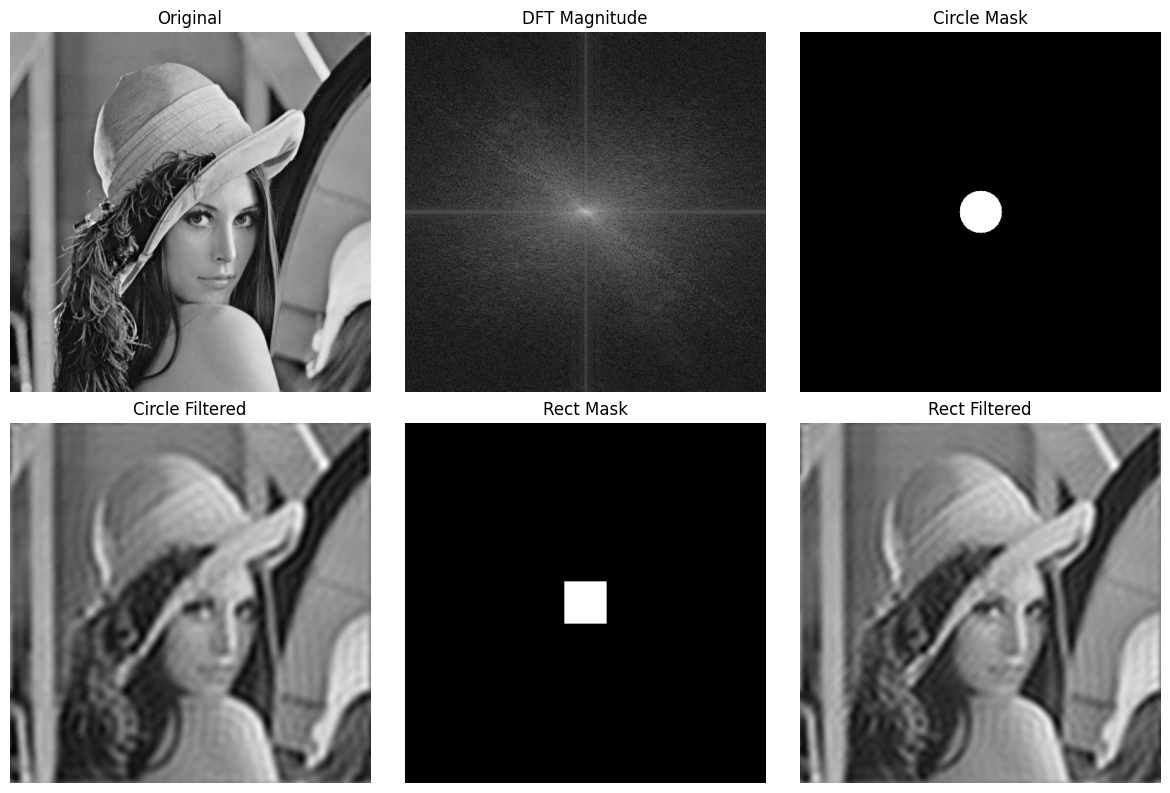

In [18]:
# === Part 2: Frequency-based Filtering ===

import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('./Lena.png', 0).astype(np.float32) / 255

# DFT 적용
fft = cv2.dft(image, flags=cv2.DFT_COMPLEX_OUTPUT)
fft_shift = np.fft.fftshift(fft, axes=[0, 1])
magnitude = cv2.magnitude(fft_shift[:, :, 0], fft_shift[:, :, 1])
magnitude = np.log(magnitude + 1)

rows, cols = image.shape
crow, ccol = rows // 2, cols // 2

# 원 모양 필터 (Low-pass)
sz_circle = 30
circle_mask = np.zeros(fft.shape, np.float32)
cv2.circle(circle_mask, (ccol, crow), sz_circle, (1, 1), -1)

# 사각형 모양 필터 (Low-pass)
sz_rect = 30
rect_mask = np.zeros(fft.shape, np.float32)
rect_mask[crow-sz_rect:crow+sz_rect, ccol-sz_rect:ccol+sz_rect, :] = 1

# 원 모양 필터 적용
fft_circle = fft_shift * circle_mask
fft_circle = np.fft.ifftshift(fft_circle, axes=[0, 1])
filtered_circle = cv2.idft(fft_circle, flags=cv2.DFT_SCALE | cv2.DFT_REAL_OUTPUT)

# 사각형 모양 필터 적용
fft_rect = fft_shift * rect_mask
fft_rect = np.fft.ifftshift(fft_rect, axes=[0, 1])
filtered_rect = cv2.idft(fft_rect, flags=cv2.DFT_SCALE | cv2.DFT_REAL_OUTPUT)

# 결과 출력
plt.figure(figsize=(12, 8))

plt.subplot(231)
plt.axis('off')
plt.title('Original')
plt.imshow(image, cmap='gray')

plt.subplot(232)
plt.axis('off')
plt.title('DFT Magnitude')
plt.imshow(magnitude, cmap='gray')

plt.subplot(233)
plt.axis('off')
plt.title('Circle Mask')
plt.imshow(circle_mask[:, :, 0], cmap='gray')

plt.subplot(234)
plt.axis('off')
plt.title('Circle Filtered')
plt.imshow(filtered_circle, cmap='gray')

plt.subplot(235)
plt.axis('off')
plt.title('Rect Mask')
plt.imshow(rect_mask[:, :, 0], cmap='gray')

plt.subplot(236)
plt.axis('off')
plt.title('Rect Filtered')
plt.imshow(filtered_rect, cmap='gray')

plt.tight_layout()
plt.show()